# Mobile Phone Market Analysis & Price Prediction

**Data source:** Raw scraped Smartprix mobile phone listings (`Mobilephone_uncleaned.csv`)

## Project objectives
1. Clean text-heavy product specifications into analysis-ready numeric fields.
2. Explore mobile-phone price patterns and relationships between hardware specifications.
3. Train and evaluate a Linear Regression model to estimate phone prices from hardware features.

> **Note:** Scraped catalog data may include unusual listings, incomplete specifications, and feature phones alongside smartphones. This notebook applies transparent, reproducible cleaning rules and filters implausible numeric values only for the modeling dataset.

## 1. Imports and configuration

This section loads the libraries used for cleaning, visualization, and predictive modeling. It also sets a consistent chart style for project-ready outputs.

In [2]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook', palette='deep')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', None)

## 2. Load and inspect the raw dataset

The raw file contains scraped text fields such as price, processor, RAM/storage, battery, display, and camera specifications. We first inspect the structure and missingness before transforming fields.

In [3]:
DATA_PATH = Path('../data/mobile_phone_market_data_raw.csv')

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f'Could not find {DATA_PATH.name}. Place the CSV in the same folder as this notebook and rerun.'
    )

raw_df = pd.read_csv(DATA_PATH)
print(f'Raw dataset shape: {raw_df.shape[0]:,} rows × {raw_df.shape[1]:,} columns')
display(raw_df.head())

missing_summary = (
    raw_df.isna().sum()
    .sort_values(ascending=False)
    .rename('missing_values')
    .to_frame()
)
missing_summary['missing_pct'] = (missing_summary['missing_values'] / len(raw_df) * 100).round(1)
display(missing_summary)

Raw dataset shape: 1,020 rows × 11 columns


,model,prices,rating,sim,processor,ram,battery,display,camera,card,os
0,Motorola Edge 70 Fusion,"₹27,589",70.0,"Dual Sim, 5G, VoLTE, Vo5G, NFC, Wi-Fi","Snapdragon 7s Gen4, Octa Core, 2.7 GHz Processor","8 GB RAM, 128 GB inbuilt",7000 mAh Battery with 68W Fast Charging,"6.8 inches, 1272 x 2772 px, 144 Hz Display wit...",50 MP + 13 MP + Dedicated 3-in-1 light sensor ...,Android v16,No FM Radio
1,Xiaomi Redmi Note 17 Pro Max,"₹49,999",NaN,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi, IR Blaster","Snapdragon 6 Gen5, Octa Core, 2.6 GHz Processor","8 GB RAM, 256 GB inbuilt",10000 mAh Battery with 100W Fast Charging,"6.83 inches, 1280 x 2772 px, 120 Hz Display wi...",50 MP + 8 MP Dual Rear & 32 MP Front Camera,Android v16,No FM Radio
2,Realme P3 5G,"₹15,999",61.0,"Dual Sim, 5G, VoLTE, NFC, Wi-Fi","Snapdragon 6 Gen4, Octa Core, 2.3 GHz Processor","6 GB RAM, 128 GB inbuilt",6000 mAh Battery with 45W Fast Charging,"6.67 inches, 1080 x 2400 px, 120 Hz Display wi...",50 MP + 2 MP Dual Rear & 16 MP Front Camera,Android v15,No FM Radio
3,Apple iPhone 18 Pro,"₹1,64,900",NaN,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi","Apple A20 Pro, Hexa Core Processor","12 GB RAM, 256 GB inbuilt",4056 mAh Battery with Fast Charging,"6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP + 48 MP Triple Rear & 18 MP Fron...,Memory Card Not Supported,iOS v27
4,Realme P3 Pro 5G (12GB RAM +256GB),"₹23,999",66.0,"Dual Sim, 5G, VoLTE, Wi-Fi","Snapdragon 7s Gen3, Octa Core, 2.5 GHz Processor","12 GB RAM, 256 GB inbuilt",6000 mAh Battery with 80W Fast Charging,"6.83 inches, 1272 x 2800 px, 120 Hz Display wi...",50 MP + 2 MP Dual Rear & 16 MP Front Camera,Android v15,No FM Radio


,missing_values,missing_pct
rating,381,37.4
os,62,6.1
card,21,2.1
camera,6,0.6
model,0,0.0
prices,0,0.0
sim,0,0.0
battery,0,0.0
ram,0,0.0
processor,0,0.0


## 3. Data cleaning and feature engineering

### Cleaning logic
- **Price:** removes `₹`, commas, and other non-numeric characters.
- **RAM and Memory:** extracts the first RAM value and the inbuilt-storage value; MB values are converted to GB.
- **Battery / Camera / Display:** extracts battery capacity (mAh), main camera resolution (MP), display size (inches), and refresh rate (Hz).
- **Processor brand:** standardizes leading processor-family labels into broad, interpretable groups.
- **Missing numeric values:** retained as `NaN` during exploration; imputed with the median inside the modeling pipeline to prevent train/test leakage.

In [4]:
def extract_first_number(value):
    """Return the first numeric token in a string, otherwise NaN."""
    if pd.isna(value):
        return np.nan
    match = re.search(r'(\d+(?:\.\d+)?)', str(value))
    return float(match.group(1)) if match else np.nan


def extract_capacity_gb(value, label):
    """Extract a memory capacity adjacent to a label (e.g., '8 GB RAM')."""
    if pd.isna(value):
        return np.nan
    match = re.search(rf'(\d+(?:\.\d+)?)\s*(GB|MB)\s*{label}', str(value), flags=re.I)
    if not match:
        return np.nan
    capacity, unit = float(match.group(1)), match.group(2).upper()
    return capacity / 1024 if unit == 'MB' else capacity


def extract_storage_gb(value):
    """Extract the capacity immediately before 'inbuilt' and convert MB to GB."""
    if pd.isna(value):
        return np.nan
    match = re.search(r'(\d+(?:\.\d+)?)\s*(GB|MB)\s*inbuilt', str(value), flags=re.I)
    if not match:
        return np.nan
    capacity, unit = float(match.group(1)), match.group(2).upper()
    return capacity / 1024 if unit == 'MB' else capacity


def extract_measurement(value, unit):
    """Extract the first number directly followed by a target unit."""
    if pd.isna(value):
        return np.nan
    match = re.search(rf'(\d+(?:\.\d+)?)\s*{unit}', str(value), flags=re.I)
    return float(match.group(1)) if match else np.nan


def extract_processor_brand(value):
    """Map raw processor text into high-level processor-brand categories."""
    if pd.isna(value):
        return 'Unknown'
    text = str(value).lower().strip()
    if 'snapdragon' in text:
        return 'Snapdragon'
    if 'dimensity' in text or 'mediatek' in text or re.search(r'\bhelio\b', text):
        return 'MediaTek'
    if 'apple' in text or re.search(r'\ba\d{1,2}(?:\s|$)', text):
        return 'Apple'
    if 'exynos' in text:
        return 'Exynos'
    if 'unisoc' in text or 'tiger' in text:
        return 'Unisoc'
    if 'kirin' in text:
        return 'Kirin'
    if 'tensor' in text:
        return 'Google Tensor'
    if 'no wifi' in text or text in {'', 'nan'}:
        return 'Unknown'
    return 'Other'


clean_df = raw_df.copy()

# Price: currency symbols and commas are removed before numeric conversion.
clean_df['price_inr'] = pd.to_numeric(
    clean_df['prices'].astype(str).str.replace(r'[^0-9.]', '', regex=True),
    errors='coerce'
)

# Hardware specifications.
clean_df['ram_gb'] = clean_df['ram'].apply(lambda x: extract_capacity_gb(x, 'RAM'))
clean_df['memory_gb'] = clean_df['ram'].apply(extract_storage_gb)
clean_df['battery_mah'] = clean_df['battery'].apply(lambda x: extract_measurement(x, 'mAh'))
clean_df['main_camera_mp'] = clean_df['camera'].apply(lambda x: extract_measurement(x, 'MP'))
clean_df['display_inches'] = clean_df['display'].apply(lambda x: extract_measurement(x, 'inches?'))
clean_df['refresh_rate_hz'] = clean_df['display'].apply(lambda x: extract_measurement(x, 'Hz'))
clean_df['processor_ghz'] = clean_df['processor'].apply(lambda x: extract_measurement(x, 'GHz'))
clean_df['processor_brand'] = clean_df['processor'].apply(extract_processor_brand)

# Optional product attributes useful for descriptive analysis.
clean_df['rating'] = pd.to_numeric(clean_df['rating'], errors='coerce')
clean_df['is_5g'] = clean_df['sim'].fillna('').str.contains('5G', case=False, regex=False).astype(int)

numeric_cols = [
    'price_inr', 'rating', 'ram_gb', 'memory_gb', 'battery_mah',
    'main_camera_mp', 'display_inches', 'refresh_rate_hz', 'processor_ghz', 'is_5g'
]

print('Cleaned feature preview:')
display(clean_df[['model', 'price_inr', 'processor_brand'] + numeric_cols[1:]].head(10))

print()
print('Numeric feature summary:')
display(clean_df[numeric_cols].describe().T.round(2))

Cleaned feature preview:


,model,price_inr,processor_brand,rating,ram_gb,memory_gb,battery_mah,main_camera_mp,display_inches,refresh_rate_hz,processor_ghz,is_5g
0,Motorola Edge 70 Fusion,27589,Snapdragon,70.0,8.0,128.0,7000.0,50.0,6.80,144.0,2.7,1
1,Xiaomi Redmi Note 17 Pro Max,49999,Snapdragon,NaN,8.0,256.0,10000.0,50.0,6.83,120.0,2.6,1
2,Realme P3 5G,15999,Snapdragon,61.0,6.0,128.0,6000.0,50.0,6.67,120.0,2.3,1
3,Apple iPhone 18 Pro,164900,Apple,NaN,12.0,256.0,4056.0,48.0,6.30,120.0,NaN,1
4,Realme P3 Pro 5G (12GB RAM +256GB),23999,Snapdragon,66.0,12.0,256.0,6000.0,50.0,6.83,120.0,2.5,1
5,Xiaomi Redmi Note 17 Pro,36999,Snapdragon,71.0,6.0,128.0,9000.0,50.0,6.83,120.0,2.4,1
6,Apple iPhone 17,82900,Apple,76.0,8.0,256.0,3692.0,48.0,6.30,120.0,NaN,1
7,Xiaomi Redmi 17 5G,23999,Snapdragon,61.0,6.0,128.0,7900.0,50.0,6.90,120.0,2.4,1
8,OnePlus Nord 5 5G,31999,Snapdragon,75.0,8.0,256.0,6800.0,50.0,6.83,144.0,3.0,1
9,Vivo T5 5G,34999,MediaTek,71.0,6.0,128.0,7050.0,50.0,6.83,144.0,2.6,1



Numeric feature summary:


,count,mean,std,min,25%,50%,75%,max
price_inr,1020.0,38456.52,44401.99,599.00,15499.00,26999.0,42999.00,449900.00
rating,639.0,64.17,7.86,50.00,58.00,64.0,70.00,79.00
ram_gb,966.0,7.38,3.64,0.00,4.00,8.0,8.00,18.00
memory_gb,953.0,182.10,125.43,0.00,128.00,128.0,256.00,512.00
battery_mah,969.0,5420.67,1628.12,600.00,5000.00,5200.0,6500.00,10001.00
main_camera_mp,900.0,51.69,37.29,0.03,48.00,50.0,50.00,200.00
display_inches,969.0,6.35,1.26,0.66,6.57,6.7,6.78,8.09
refresh_rate_hz,811.0,121.59,14.44,90.00,120.00,120.0,120.00,165.00
processor_ghz,820.0,2.69,0.62,1.00,2.40,2.5,3.00,4.74
is_5g,1020.0,0.76,0.43,0.00,1.00,1.0,1.00,1.00


### Data-quality checks

We preserve the original scraped columns and work from engineered numeric fields. The following table verifies missingness after extraction and makes the cleaning process auditable.

In [5]:
feature_quality = pd.DataFrame({
    'non_null_count': clean_df[numeric_cols].notna().sum(),
    'missing_count': clean_df[numeric_cols].isna().sum(),
    'missing_pct': (clean_df[numeric_cols].isna().mean() * 100).round(1),
    'min': clean_df[numeric_cols].min(),
    'max': clean_df[numeric_cols].max(),
}).round(2)
display(feature_quality)

,non_null_count,missing_count,missing_pct,min,max
price_inr,1020,0,0.0,599.00,449900.00
rating,639,381,37.4,50.00,79.00
ram_gb,966,54,5.3,0.00,18.00
memory_gb,953,67,6.6,0.00,512.00
battery_mah,969,51,5.0,600.00,10001.00
main_camera_mp,900,120,11.8,0.03,200.00
display_inches,969,51,5.0,0.66,8.09
refresh_rate_hz,811,209,20.5,90.00,165.00
processor_ghz,820,200,19.6,1.00,4.74
is_5g,1020,0,0.0,0.00,1.00


## 4. Exploratory data analysis (EDA)

The following visualizations answer three business questions:
1. How are listed mobile-phone prices distributed?
2. Which numeric hardware specifications move together?
3. How do average prices differ across the most represented processor brands?

### 4.1 Price distribution curve

A histogram with KDE shows the distribution of catalog prices. Since mobile prices are typically right-skewed, the chart focuses on the 99th percentile to keep extreme listings from obscuring the main market.

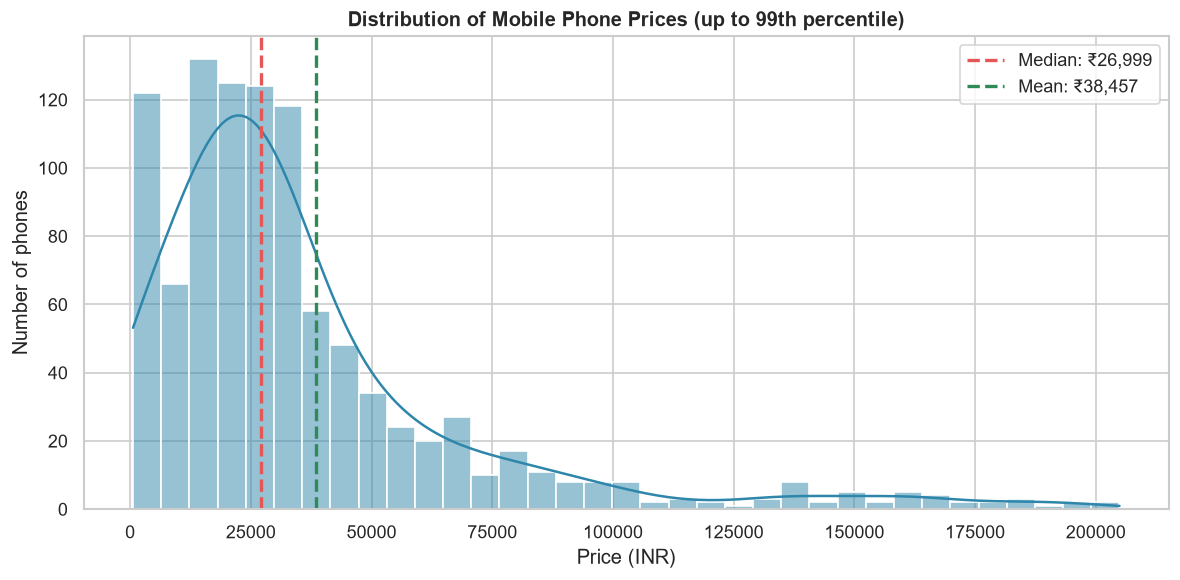

In [6]:
plot_prices = clean_df['price_inr'].dropna()
price_cap = plot_prices.quantile(0.99)

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(plot_prices[plot_prices <= price_cap], bins=35, kde=True, color='#2E86AB', ax=ax)

ax.axvline(plot_prices.median(), color='#E45756', linestyle='--', linewidth=2,
           label=f'Median: ₹{plot_prices.median():,.0f}')
ax.axvline(plot_prices.mean(), color='#2E8B57', linestyle='--', linewidth=2,
           label=f'Mean: ₹{plot_prices.mean():,.0f}')

ax.set_title('Distribution of Mobile Phone Prices (up to 99th percentile)', weight='bold')
ax.set_xlabel('Price (INR)')
ax.set_ylabel('Number of phones')
ax.legend()
plt.tight_layout()
plt.show()

### 4.2 Correlation heatmap

This heatmap focuses on the required core variables: RAM, Memory, Battery, and Price. Correlations are Pearson correlations computed using available pairs of records.

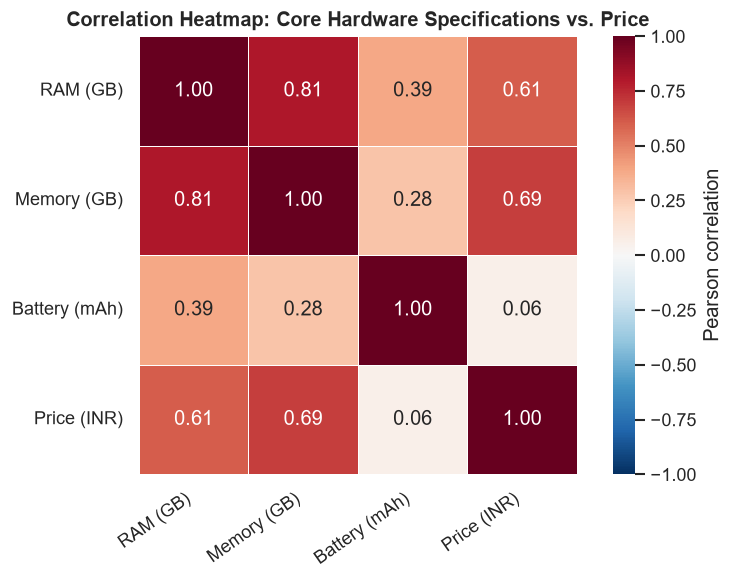

In [7]:
corr_features = ['ram_gb', 'memory_gb', 'battery_mah', 'price_inr']
corr_matrix = clean_df[corr_features].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Pearson correlation'},
    ax=ax,
)
ax.set_title('Correlation Heatmap: Core Hardware Specifications vs. Price', weight='bold')
ax.set_xticklabels(['RAM (GB)', 'Memory (GB)', 'Battery (mAh)', 'Price (INR)'], rotation=35, ha='right')
ax.set_yticklabels(['RAM (GB)', 'Memory (GB)', 'Battery (mAh)', 'Price (INR)'], rotation=0)
plt.tight_layout()
plt.show()

### 4.3 Average price across top processor brands

To avoid unstable averages from very rare categories, the chart uses the five processor brands with the largest number of catalog listings.

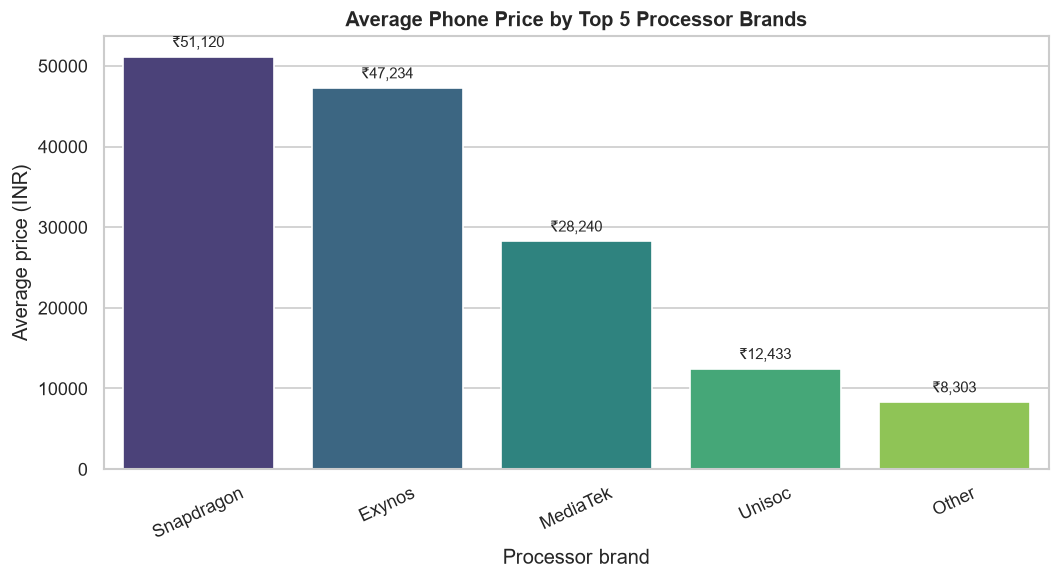

,phone_count,average_price
processor_brand,,
Snapdragon,314,51120.0
Exynos,63,47234.0
MediaTek,380,28240.0
Unisoc,78,12433.0
Other,107,8303.0


In [8]:
brand_summary = (
    clean_df.dropna(subset=['price_inr'])
    .groupby('processor_brand')
    .agg(phone_count=('model', 'size'), average_price=('price_inr', 'mean'))
    .sort_values('phone_count', ascending=False)
    .head(5)
    .sort_values('average_price', ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=brand_summary.reset_index(),
    x='processor_brand',
    y='average_price',
    palette='viridis',
    ax=ax,
)
ax.set_title('Average Phone Price by Top 5 Processor Brands', weight='bold')
ax.set_xlabel('Processor brand')
ax.set_ylabel('Average price (INR)')
ax.tick_params(axis='x', rotation=25)
for patch, value in zip(ax.patches, brand_summary['average_price']):
    ax.annotate(
        f'₹{value:,.0f}',
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha='center', va='bottom', xytext=(0, 4), textcoords='offset points', fontsize=9
    )
plt.tight_layout()
plt.show()

display(brand_summary.assign(average_price=lambda d: d['average_price'].round(0)))

## 5. Predictive modeling: Linear Regression

### Modeling target and features
The target is **listed price in INR**. The model uses hardware specifications plus processor brand:
- Numeric: RAM, storage memory, battery capacity, main-camera resolution, display size, refresh rate, and processor clock speed.
- Categorical: processor brand (one-hot encoded).

### Validation approach
- A **80/20 train-test split** is used with a fixed random seed for reproducibility.
- Missing numeric feature values are imputed with training-set medians inside a Scikit-Learn pipeline.
- Basic plausibility filters exclude obvious extraction anomalies (for example, tiny feature-phone memory values or unusually low processor readings) from the regression sample. This keeps the model focused on comparable smartphone listings while retaining the full cleaned dataset for EDA.

In [9]:
model_features_num = [
    'ram_gb', 'memory_gb', 'battery_mah', 'main_camera_mp',
    'display_inches', 'refresh_rate_hz', 'processor_ghz'
]
model_features_cat = ['processor_brand']
target = 'price_inr'

# Plausibility filters for a more consistent smartphone-specification regression dataset.
model_df = clean_df.copy()
model_df = model_df[
    model_df[target].between(1_000, 300_000)
    & model_df['ram_gb'].between(1, 32)
    & model_df['memory_gb'].between(4, 2_048)
    & model_df['battery_mah'].between(500, 15_000)
    & model_df['display_inches'].between(2, 9)
    & model_df['main_camera_mp'].between(0.1, 300)
]

X = model_df[model_features_num + model_features_cat]
y = model_df[target]

print(f'Modeling observations after quality filters: {len(model_df):,}')
print(f'Features: {X.columns.tolist()}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer(transformers=[
    ('numeric', numeric_transformer, model_features_num),
    ('categorical', categorical_transformer, model_features_cat),
])

price_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression()),
])

price_model.fit(X_train, y_train)
y_pred = price_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print('Linear Regression evaluation (test set)')
print(f'R-squared (R²): {r2:.3f}')
print(f'RMSE: ₹{rmse:,.0f}')

Modeling observations after quality filters: 846
Features: ['ram_gb', 'memory_gb', 'battery_mah', 'main_camera_mp', 'display_inches', 'refresh_rate_hz', 'processor_ghz', 'processor_brand']
Linear Regression evaluation (test set)
R-squared (R²): 0.743
RMSE: ₹12,277


### 5.1 Actual vs. predicted prices

This diagnostic plot helps assess whether predictions are generally aligned with observed prices. Points near the dashed line represent more accurate predictions.

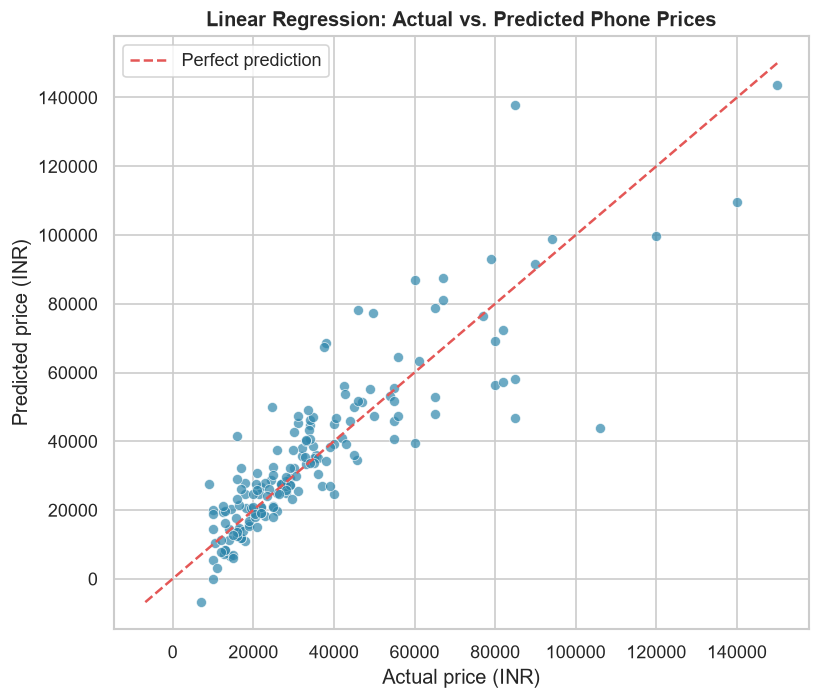

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='#2E86AB', ax=ax)
line_min = min(y_test.min(), y_pred.min())
line_max = max(y_test.max(), y_pred.max())
ax.plot([line_min, line_max], [line_min, line_max], '--', color='#E45756', label='Perfect prediction')
ax.set_title('Linear Regression: Actual vs. Predicted Phone Prices', weight='bold')
ax.set_xlabel('Actual price (INR)')
ax.set_ylabel('Predicted price (INR)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Conclusions

- **Price distribution:** Mobile-phone prices are strongly right-skewed, with a median of approximately **₹26,999** and a higher mean of about **₹38,457**, indicating the influence of higher-priced phones.

- **Hardware relationships:** **Storage and RAM** show the strongest positive association with price, while **battery capacity** has a comparatively weak relationship.

- **Processor positioning:** The five highest-volume processor groups show distinct mean price tiers, with **Snapdragon and Exynos** positioned at higher average prices and **MediaTek, Unisoc, and Other** at lower levels.

- **Model performance:** The Linear Regression baseline achieved a held-out **R² of 0.743** and **RMSE of approximately ₹12,277**, explaining a substantial portion of price variation while leaving room for further improvement.

### Possible extensions

- Add features such as charging wattage, display resolution, OS version, and 5G support.
- Test log-price modeling and tree-based ensemble models.
- Build an interactive Power BI or Plotly dashboard.